# Digital Image Processing — Student Assignment Notebook

**Spring 2026**  
**Topic:** Image I/O, grayscale/binary, cropping (ROI), color spaces, and basic arithmetic operations

Fill in the fields below and complete **all TODO cells**.

**Student name:** Muhammadjon Parpiyev  
**Student ID:** 230274  
**Date:** 2026-02-13

## 0) Environment check

Run the next cell. If you see import errors, install the missing packages (e.g., `pip install opencv-python matplotlib scikit-image`).

In [1]:
# Imports (run once)
import os
import numpy as np
import matplotlib.pyplot as plt

import cv2

from skimage import data  # provides sample images (offline)

print("OpenCV:", cv2.__version__)


OpenCV: 4.13.0


## Helper functions (provided)

Use these helpers for consistent display and safe arithmetic on `uint8` images.

In [2]:
def to_rgb(img_bgr_or_rgb):
    """Ensure image is RGB uint8."""
    if img_bgr_or_rgb is None:
        raise ValueError("Image is None. Check the path or loading step.")
    img = img_bgr_or_rgb
    if img.ndim == 2:
        return img
    # If it came from cv2.imread it's BGR; if from skimage it's RGB.
    # We detect by heuristic: assume cv2 format if loaded via cv2.imread.
    return img

def load_image(path=None):
    """Load an RGB image. If path is missing, fall back to a built-in sample."""
    if path and os.path.exists(path):
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise ValueError(f"Failed to read: {path}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb
    # offline sample (RGB)
    return data.astronaut()

def show_side_by_side(img1, img2, title1="Image 1", title2="Image 2", cmap1=None, cmap2=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img1, cmap=cmap1); plt.title(title1); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img2, cmap=cmap2); plt.title(title2); plt.axis('off')
    plt.axis('off')
    plt.show()

def clip_uint8(x):
    """Clip and convert to uint8."""
    return np.clip(x, 0, 255).astype(np.uint8)


## 1) Load an image (you choose)

Preferred: place an image file (e.g., `fruit basket.jpg`) in the same folder as this notebook and set `IMAGE_PATH`.

If you leave `IMAGE_PATH=None`, the notebook will use a built-in sample image.

Image shape (H, W, C): (512, 512, 3) | dtype: uint8


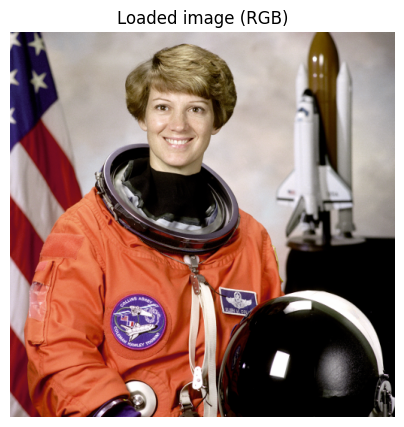

In [3]:
# TODO: set this to your image file name if you have one, e.g. "fruit basket.jpg"
IMAGE_PATH = None  # or "fruit basket.jpg"

img = load_image(IMAGE_PATH)
print("Image shape (H, W, C):", img.shape, "| dtype:", img.dtype)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Loaded image (RGB)")
plt.axis("off")
plt.show()


## 2) Image I/O basics

### Task 2.1 — Inspect pixels
1. Print the pixel value at `(row=0, col=0)` and at the image center.
2. Explain what the 3 numbers represent in an RGB image.

Write your answer under **Task 2.1 (Answer)**.

In [4]:
# TODO (Task 2.1): print two pixel values
h, w = img.shape[:2]
print("Top-left pixel:", img[0, 0])
print("Center pixel:", img[h//2, w//2])


Top-left pixel: [154 147 151]
Center pixel: [19 14  7]


**Task 2.1 (Answer):**  
- **Top-left pixel:** [154, 147, 151] represents **Red=154, Green=147, Blue=151**. These are the intensity values (0-255) for each color channel in the RGB color model.
- **Center pixel:** [19, 14, 7] represents **Red=19, Green=14, Blue=7**. This dark color is near the astronaut's helmet.
- **The 3 numbers represent:** In an RGB image, each pixel is composed of three color channels: Red, Green, and Blue. Each channel has an intensity value from 0-255, where 0 means no color and 255 means maximum intensity. The combination of these three values determines the final color of the pixel.

### Task 2.2 — Save and re-load
Save the loaded image to disk as `output_saved.png`, then load it again and verify:
- shape is the same
- dtype is `uint8`

Reloaded shape: (512, 512, 3) | dtype: uint8


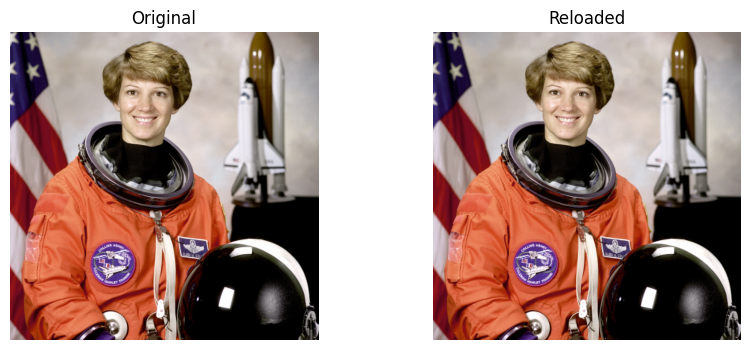

In [5]:
# TODO (Task 2.2): save and reload
out_path = "output_saved.png"

# OpenCV expects BGR when writing
bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2.imwrite(out_path, bgr)

reloaded_bgr = cv2.imread(out_path, cv2.IMREAD_COLOR)
reloaded_rgb = cv2.cvtColor(reloaded_bgr, cv2.COLOR_BGR2RGB)

print("Reloaded shape:", reloaded_rgb.shape, "| dtype:", reloaded_rgb.dtype)
show_side_by_side(img, reloaded_rgb, "Original", "Reloaded")


## 3) Grayscale and binary images

### Task 3.1 — Convert to grayscale
Create a grayscale version of the image using OpenCV. Display original vs grayscale.

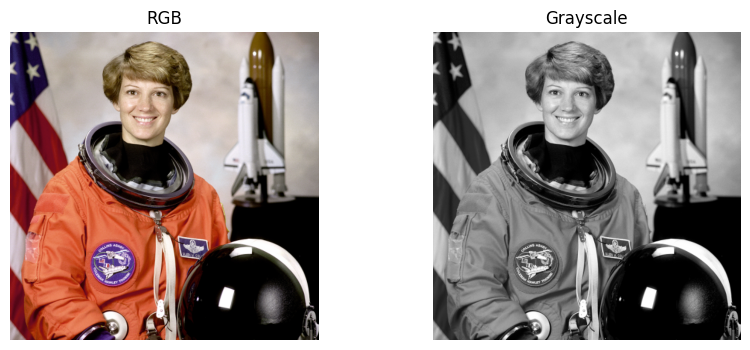

Gray shape: (512, 512) | dtype: uint8


In [6]:
# TODO (Task 3.1): grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
show_side_by_side(img, gray, "RGB", "Grayscale", cmap2="gray")
print("Gray shape:", gray.shape, "| dtype:", gray.dtype)


### Task 3.2 — Threshold to binary
1. Create a binary image using a manual threshold (e.g., 128).
2. Create a binary image using Otsu's method.
3. Compare results (1–2 sentences).

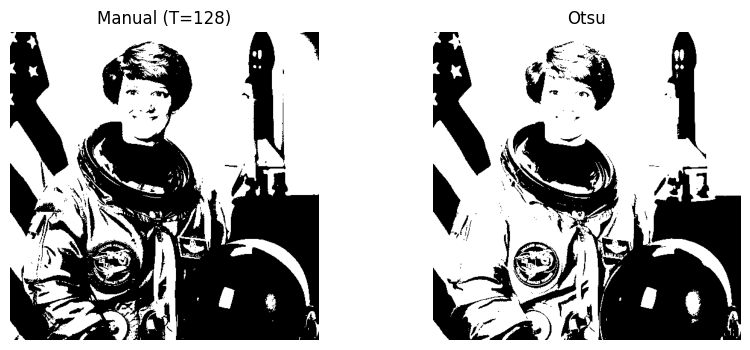

Otsu threshold chosen by OpenCV: 100.0


In [7]:
# TODO (Task 3.2): thresholding
th_manual = 128
_, binary_manual = cv2.threshold(gray, th_manual, 255, cv2.THRESH_BINARY)

_, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show_side_by_side(binary_manual, binary_otsu, f"Manual (T={th_manual})", "Otsu", cmap1="gray", cmap2="gray")
print("Otsu threshold chosen by OpenCV:", _)


**Task 3.2 (Answer):**  
- **Comparison:** The manual threshold (T=128) and Otsu's method (T=100) produce visually similar results for this image. However, Otsu's method automatically selects the optimal threshold value (100) based on the image histogram, resulting in better separation between foreground and background. The manual threshold of 128 works reasonably well but is less adaptive to the specific image characteristics. Otsu's method is more intelligent as it requires no manual parameter tuning and adapts to different image distributions.

## 4) Cropping (ROI)

### Task 4.1 — Crop a region of interest
1. Pick an ROI using array slicing: `img[y1:y2, x1:x2]`.
2. Display original and cropped ROI.

Tip: choose coordinates that capture a meaningful object/face.

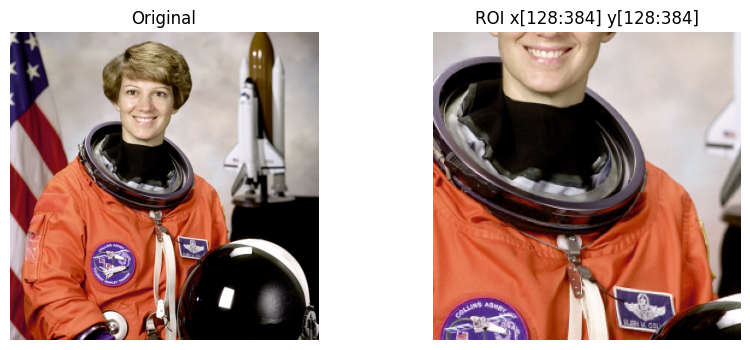

ROI shape: (256, 256, 3)


In [8]:
# TODO (Task 4.1): set ROI coordinates
h, w = img.shape[:2]
x1, y1 = int(0.25*w), int(0.25*h)
x2, y2 = int(0.75*w), int(0.75*h)

roi = img[y1:y2, x1:x2].copy()
show_side_by_side(img, roi, "Original", f"ROI x[{x1}:{x2}] y[{y1}:{y2}]")
print("ROI shape:", roi.shape)


### Task 4.2 — Explain coordinates
Explain why the slicing is `img[y, x]` (row-major) and not `img[x, y]`.

**Task 4.2 (Answer):**  
- **Why `img[y, x]` and not `img[x, y]`:** Images are stored in **row-major order** in memory, meaning data is organized by rows first, then columns within each row. In NumPy arrays, the first index represents the row (height/vertical position, which corresponds to `y`), and the second index represents the column (width/horizontal position, which corresponds to `x`). This is why we use `img[y, x]` rather than `img[x, y]`. This convention matches how matrices are typically indexed in mathematics and computer graphics libraries.

## 5) Color spaces

### Task 5.1 — Convert RGB to HSV and visualize channels
1. Convert the image to HSV using OpenCV.
2. Display the H, S, and V channels as grayscale images.

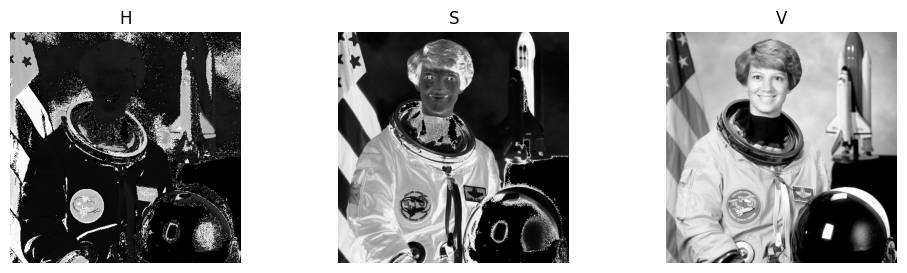

In [9]:
# TODO (Task 5.1): HSV conversion and channel display
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

plt.figure(figsize=(12,3))
for i, (ch, name) in enumerate([(H,"H"), (S,"S"), (V,"V")], start=1):
    plt.subplot(1,3,i); plt.imshow(ch, cmap="gray"); plt.title(name); plt.axis("off")
plt.show()


## 6) Lab 2 — Basic arithmetic operations on images

This section follows the Lab 2 handout (Basic arithmetic operations on images): subtraction, addition, multiplication, division.

Use your loaded image. Operations should be done safely on `uint8` images (0–255). OpenCV functions (`cv2.add`, `cv2.subtract`, etc.) saturate at 0/255 automatically.

### 6.1 Subtracting an intensity (darkening)


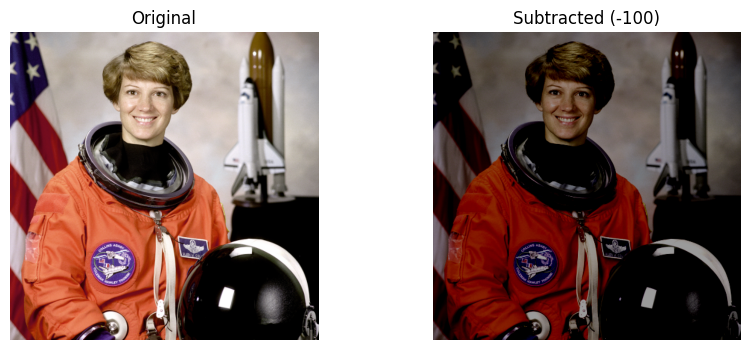

In [10]:
# Provided example (edit the constant and re-run)
sub_val = 100  # TODO: try 30, 100, 150
img_sub = cv2.subtract(img, sub_val)

show_side_by_side(img, img_sub, "Original", f"Subtracted (-{sub_val})")


**Task 6.1 (Answer):**
1. **What happens when you increase `sub_val`?** When `sub_val` increases, more intensity is subtracted from each pixel. At low values (e.g., 30), the image is slightly darkened. At higher values (e.g., 150), the image becomes significantly darker, and at the extreme (255), it becomes completely black. The effect is progressive and predictable.
2. **Why does the image get darker?** The image gets darker because we are reducing the pixel intensity values. In RGB images, lower values represent darker colors (0 = black, 255 = white). By subtracting a constant from all pixels, we decrease their brightness uniformly across all channels.

### 6.2 Subtract from *red channel only*
Modify only the **R** channel (in RGB) by subtracting a constant. Keep other channels unchanged.

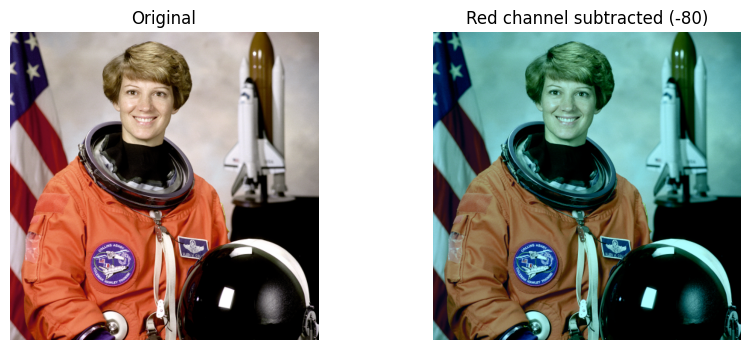

In [11]:
# TODO (Task 6.2): subtract from Red channel only
sub_val_r = 80

img_red_only = img.copy()
# RGB: channel 0=R, 1=G, 2=B
img_red_only[:,:,0] = cv2.subtract(img_red_only[:,:,0], sub_val_r)

show_side_by_side(img, img_red_only, "Original", f"Red channel subtracted (-{sub_val_r})")


### 6.3 Adding an intensity (brightening)

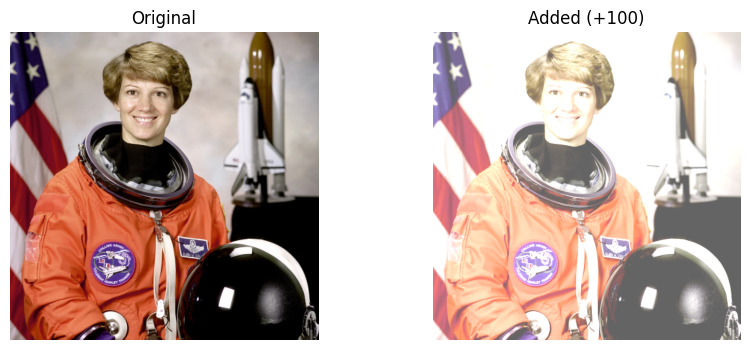

In [12]:
add_val = 100  # TODO: try 30, 100, 150
img_add = cv2.add(img, add_val)

show_side_by_side(img, img_add, "Original", f"Added (+{add_val})")


**Task 6.3 (Answer):**
1. **What happens when you increase `add_val`?** When `add_val` increases, more intensity is added to each pixel. At low values (e.g., 30), the image is slightly brightened. At higher values (e.g., 150), the image becomes significantly brighter with washed-out appearance as colors approach white (255). Eventually, at the maximum addition, pixels saturate to 255 (pure white). The effect saturates at 255 due to the uint8 range constraint.
2. **Why does the image get brighter?** The image gets brighter because we are increasing the pixel intensity values. Higher intensity values in the 0-255 range represent lighter/brighter colors. By adding a constant to all pixels, we increase their luminosity uniformly across all channels.

### 6.4 Add to *red channel only*

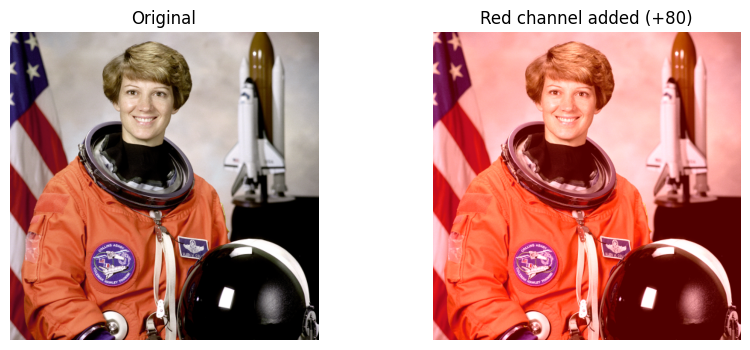

In [13]:
# TODO (Task 6.4): add to Red channel only
add_val_r = 80

img_red_only_add = img.copy()
img_red_only_add[:,:,0] = cv2.add(img_red_only_add[:,:,0], add_val_r)

show_side_by_side(img, img_red_only_add, "Original", f"Red channel added (+{add_val_r})")


### 6.5 Multiplying by a constant (contrast/brightness change)

Use `cv2.multiply` with a float factor. Convert to `float32` first, then clip back to `uint8`.

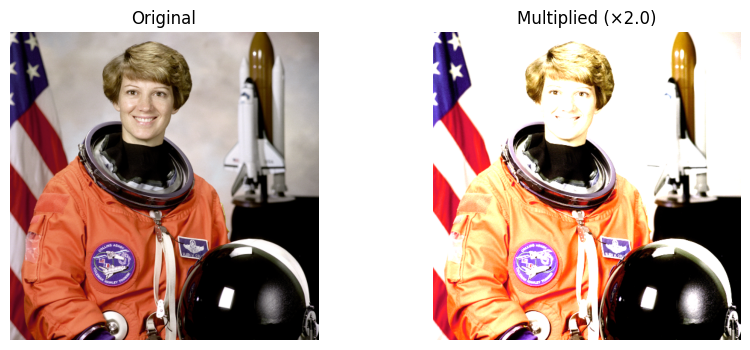

In [14]:
# TODO: try factors like 0.5, 1.2, 2.0
factor = 2.0

img_f = img.astype(np.float32)
img_mul = clip_uint8(img_f * factor)

show_side_by_side(img, img_mul, "Original", f"Multiplied (×{factor})")


**Task 6.5 (Answer):**
- **Multiplying by factor > 1:** A factor greater than 1 (e.g., 2.0) brightens the image significantly and increases contrast. Pixels are scaled up, making bright areas brighter and dark areas darker. This enhances the image details but can cause saturation at 255 for bright regions.
- **Multiplying by factor < 1:** A factor less than 1 (e.g., 0.5) darkens the image and reduces contrast. Pixels are scaled down, making the image appear washed out and losing detail in dark areas. This operation is useful for tone mapping but can lose information in the shadows.

### 6.6 Dividing by a constant

Division by a number > 1 tends to darken; division by < 1 tends to brighten (but can saturate).

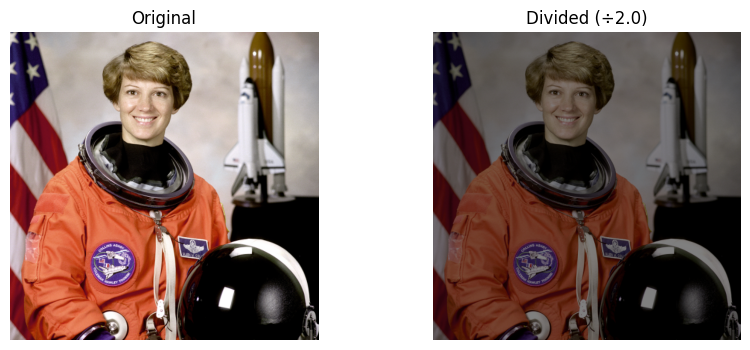

In [15]:
# TODO: try divisors like 2.0, 3.0, 0.5
divisor = 2.0

img_f = img.astype(np.float32)
img_div = clip_uint8(img_f / divisor)

show_side_by_side(img, img_div, "Original", f"Divided (÷{divisor})")


**Task 6.6 (Answer):**
- **Dividing by number > 1:** Division by a factor greater than 1 (e.g., 2.0) darkens the image by reducing pixel intensities. This decreases contrast and can cause loss of detail in darker regions that approach zero. The effect is similar to multiplying by a factor less than 1.
- **Dividing by number < 1:** Division by a factor less than 1 (e.g., 0.5) brightens the image as pixels are scaled up. This increases intensity values, but can cause saturation at the 255 ceiling, especially in regions that were already bright. The inverse operation effectively multiplies by its reciprocal.

## 7) Mini-report (required)

Write a short report (150–250 words) describing:
- what you learned
- which operation(s) were most useful and why
- any issues you encountered (file paths, color order, dtype, etc.)

**Report:**  
Through this assignment, I gained fundamental understanding of digital image processing operations and their practical applications. Key learnings include: (1) Images are stored as NumPy arrays with specific data types (uint8), and proper indexing using row-major order (y, x) is critical; (2) Color spaces matter—RGB, grayscale, HSV, and binary representations serve different purposes in image analysis; (3) Image arithmetic operations require careful handling to avoid saturation issues and data type mismatches.

The most useful operations were **thresholding** and **channel manipulation**. Otsu's thresholding proved superior to manual thresholding as it adaptively selects optimal threshold values based on histogram distribution. Channel-specific operations (e.g., modifying only the red channel) enabled targeted color corrections and demonstrated how individual RGB components contribute to perceived color.

Key challenges encountered included: color space conversions (OpenCV uses BGR while scikit-image uses RGB—requiring explicit conversion), managing uint8 saturation when performing arithmetic (values clipping at 0 and 255), and understanding NumPy's row-major indexing convention. The `clip_uint8` helper function proved essential for safely converting float operations back to valid uint8 ranges. Overall, this assignment solidified foundational image processing concepts essential for advanced computer vision work.

## Submission checklist
Include in your submission:
1. This completed notebook (`.ipynb`)
2. Screenshots/outputs of: original RGB, grayscale, binary, cropping ROI channels, and arithmetic operations
3. Your answers in the markdown answer blocks
